In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import BinaryEncoder as ce


In [25]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [28]:
df["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [29]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [30]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [31]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [32]:
encoder = ce(cols=["sex", "smoker"])

In [33]:
df_encoded = encoder.fit_transform(df)

In [34]:
df = df_encoded.drop(columns=["sex_0", "smoker_0"])

In [35]:
df.head()

,age,sex_1,bmi,children,smoker_1,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [36]:
df = pd.get_dummies(columns=["region"], data = df, drop_first= True)

<Axes: >

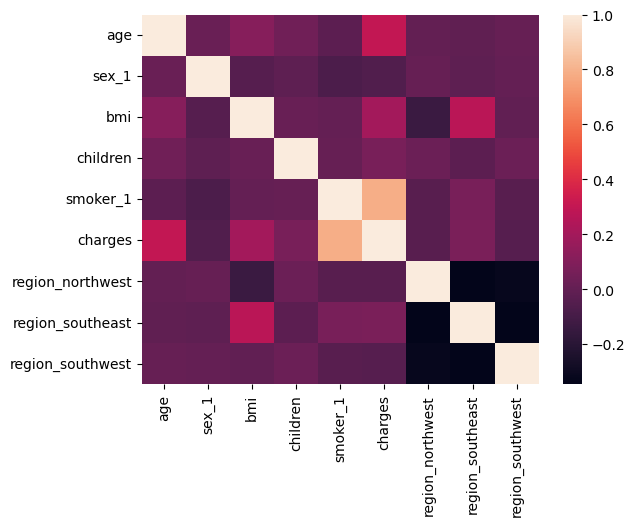

In [37]:
sns.heatmap(df.corr())

<Axes: xlabel='bmi', ylabel='charges'>

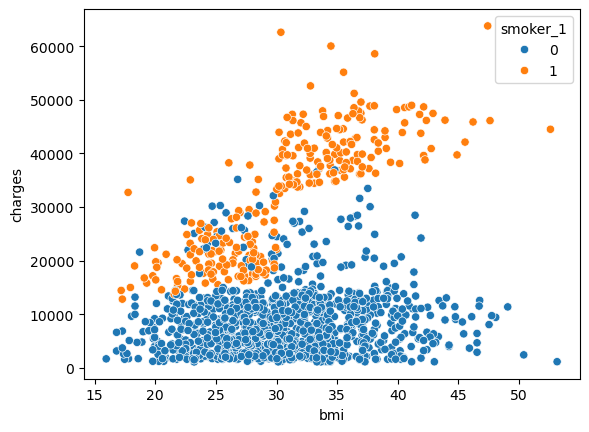

In [38]:
sns.scatterplot(x="bmi", y="charges", hue="smoker_1", data=df)

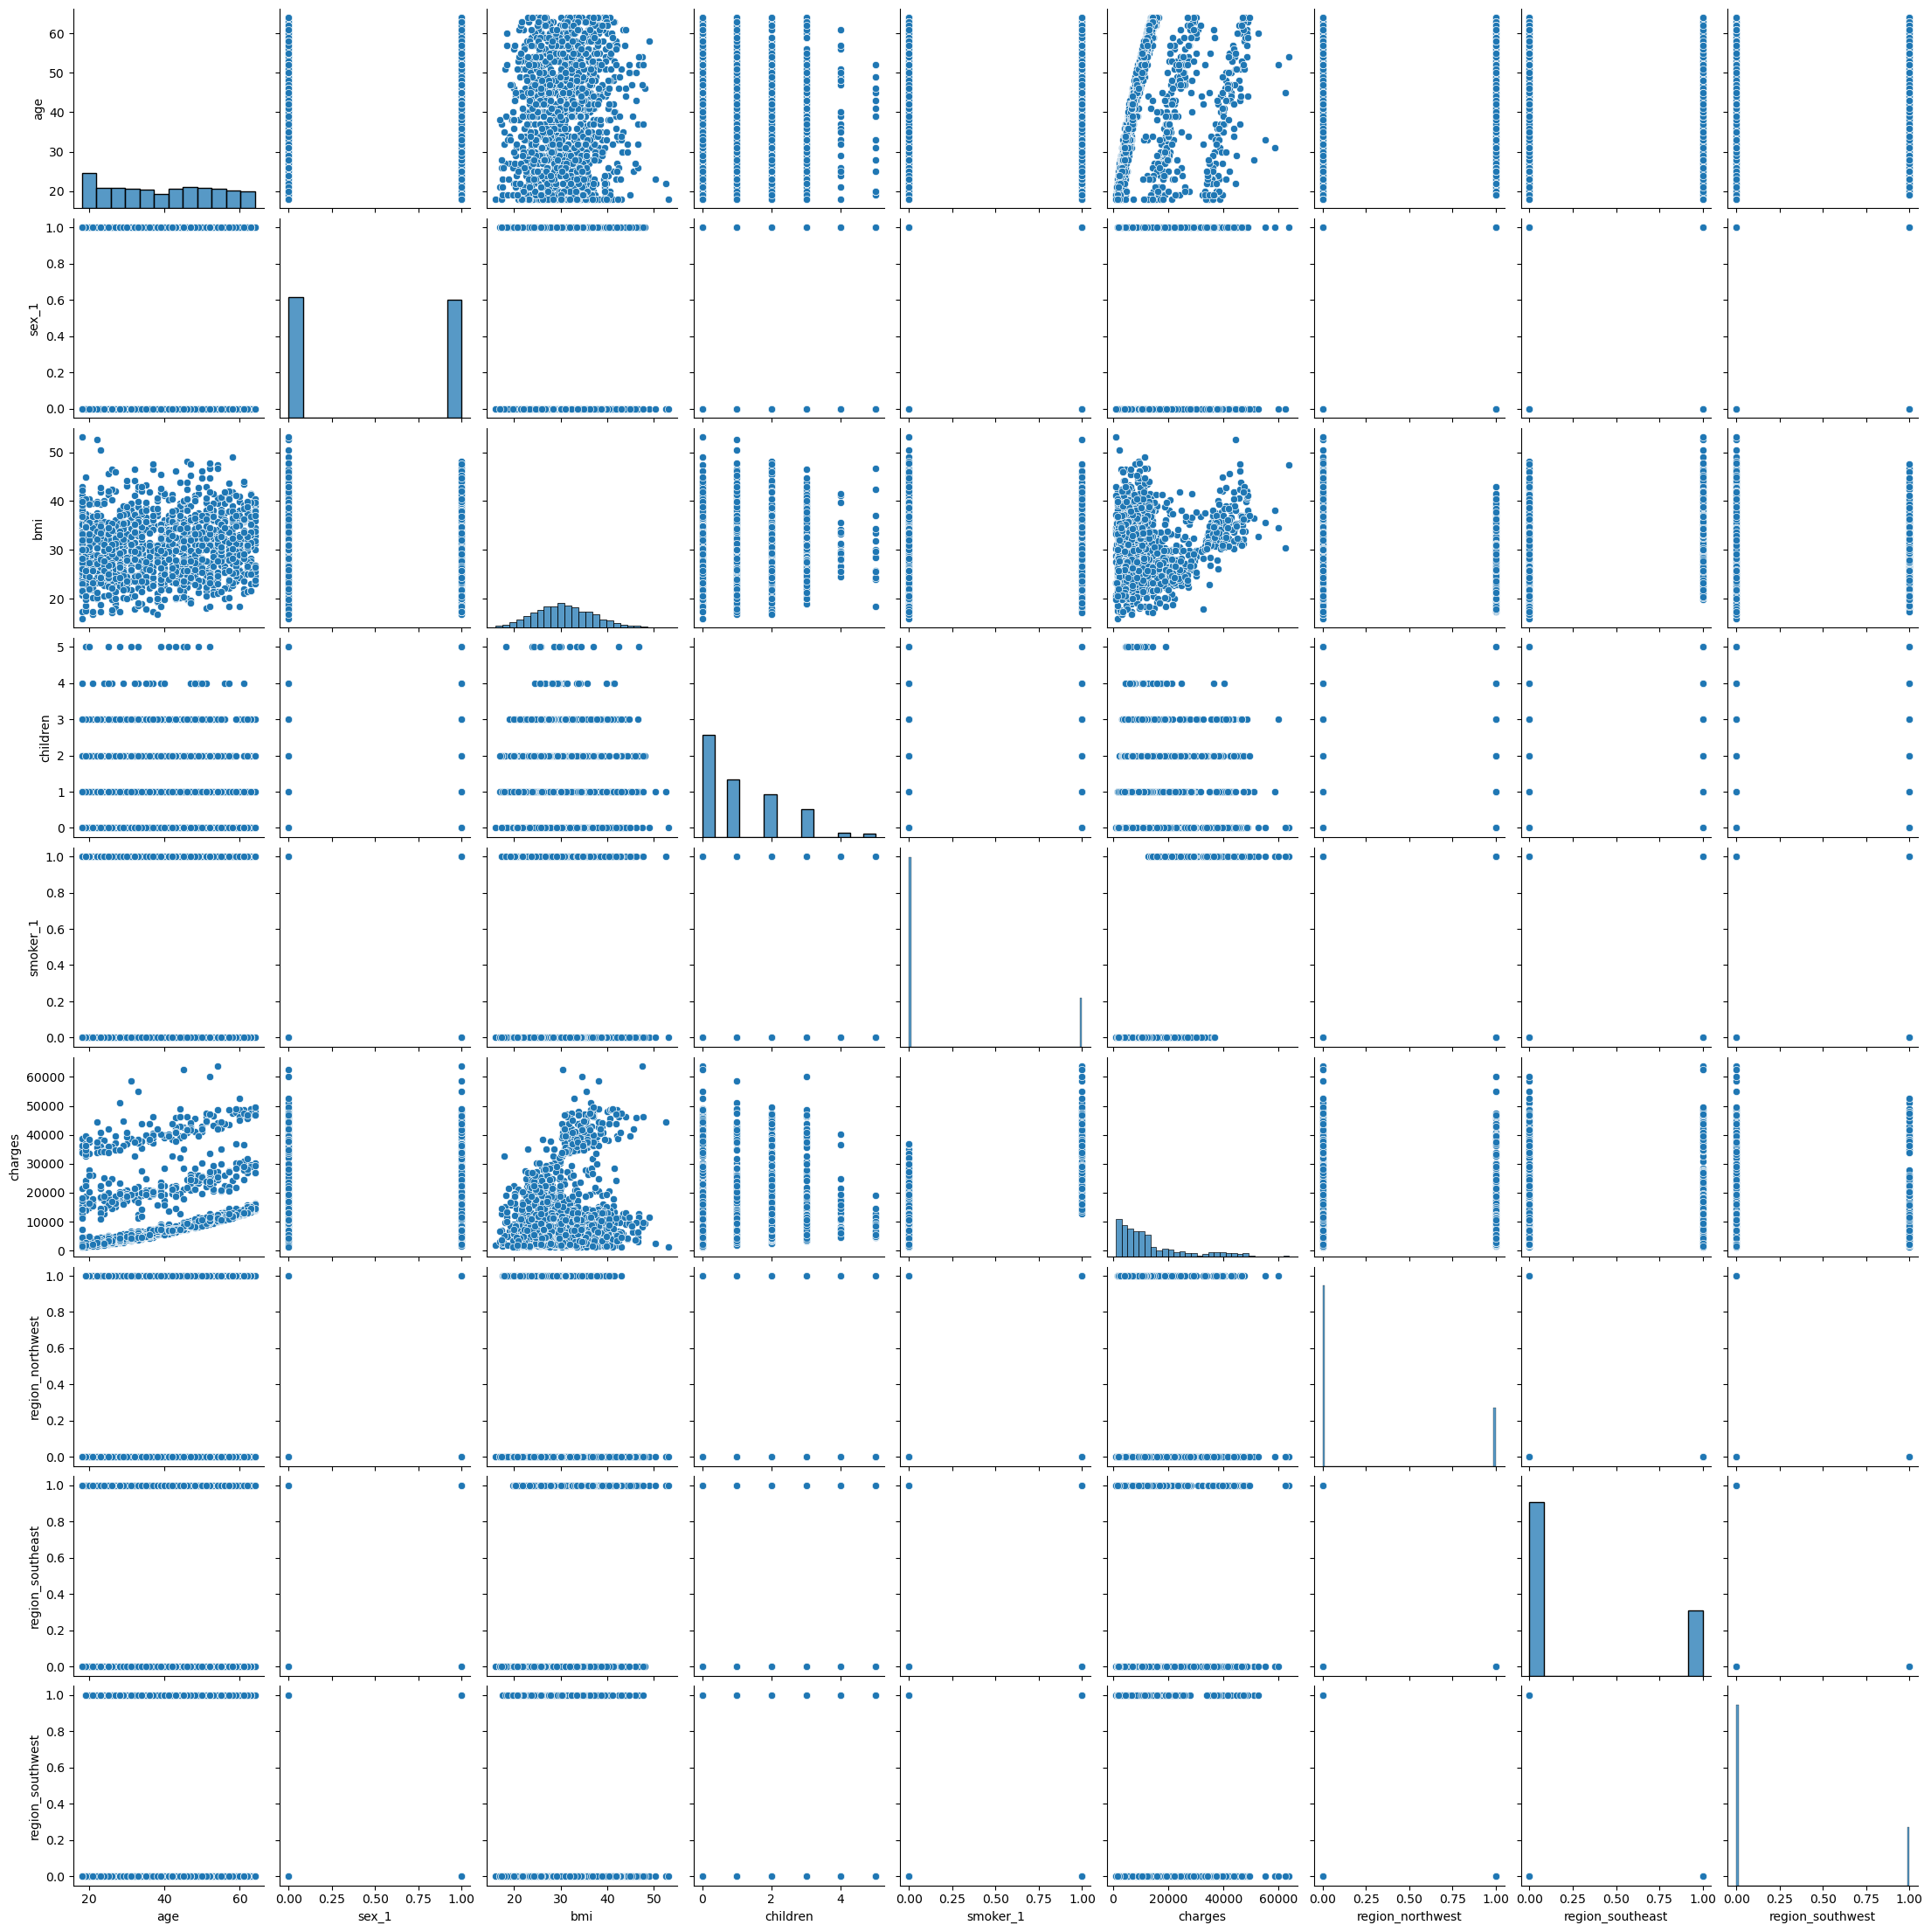

In [39]:
sns.pairplot(df)
plt.show()

In [40]:
df.head()

,age,sex_1,bmi,children,smoker_1,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [41]:
X = df[["age", "sex_1", "bmi", "children", "smoker_1"]]
y = df["charges"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [43]:
regression = LinearRegression()

In [44]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred = regression.predict(X_test)

In [46]:
r2_score(y_test, y_pred)

0.7811302113434097

In [47]:
mean_absolute_error(y_test ,y_pred)

4213.484797807134

In [48]:
mean_squared_error(y_test, y_pred)

33979257.050808206

In [49]:
regression.coef_

array([2.57068962e+02, 7.95178837e+00, 3.27533514e+02, 4.27254431e+02,
       2.36539033e+04])

In [50]:
df_smoker = df[df["smoker_1"] == 1]
df_nonsmoker = df[df["smoker_1"] == 0]

In [54]:
X = df_smoker[["age", "sex_1", "bmi", "children", "smoker_1"]]
y = df_smoker["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [55]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = regression.predict(X_test)

In [57]:
r2_score(y_test, y_pred)

0.7010548269745505

In [65]:
X = df[["age", "sex_1", "bmi", "children"]]
y = df["charges"]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)


In [67]:
regression.fit(X_train, y_train)
y_pred = regression.predict(X_test)
r2_score(y_test, y_pred)

0.1573520450972109